# Análisis de Churn

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from src.models import ThresholdRuleClassifier

## Generación Sintética de Datos

In [2]:
np.random.seed(42)
n = 1200
df = pd.DataFrame({
    'customer_id': range(n),
    'age': np.random.randint(22, 65, n),
    'tenure_months': np.random.randint(1, 72, n),
    'monthly_charges': np.round(np.random.uniform(20, 200, n), 2),
    'num_products': np.random.randint(1, 6, n),
    'has_support_contract': np.random.randint(0, 2, n),
    'last_login_days_ago': np.random.randint(0, 180, n),
    'support_tickets_6m': np.random.poisson(1.5, n),
})
# Target con señal realista
churn_prob = (
    0.03 * df['last_login_days_ago'] / 180 * 5 +
    0.04 * df['support_tickets_6m'] +
    0.02 * (1 / df['num_products']) * 3 -
    0.01 * df['tenure_months'] / 72 * 2 + np.random.normal(0, 0.05, n)
)
df['churned'] = (churn_prob > churn_prob.quantile(0.72)).astype(int)

## Parte 1 - Análisis Exploratorio

1. Muestra las primeras filas, tipos de dato y estadísticas básicas del dataset.

Soy consciente de que siendo rigurosos debería convertir ``has_support_contract`` y ``churned`` a booleanos pero es irrelevante para entrenar los modelos y para el análisis exploratorio (a mi saber), así que voy a obviarlo.

In [3]:
display(df.head(5))
display(df.dtypes)
df.describe()

,customer_id,age,tenure_months,monthly_charges,num_products,has_support_contract,last_login_days_ago,support_tickets_6m,churned
0,0,60,53,21.27,5,0,16,2,0
1,1,50,44,30.31,5,0,37,1,0
2,2,36,24,60.54,4,0,141,0,1
3,3,64,30,43.64,2,0,109,2,1
4,4,29,59,91.79,1,1,21,3,1


customer_id               int64
age                       int64
tenure_months             int64
monthly_charges         float64
num_products              int64
has_support_contract      int64
last_login_days_ago       int64
support_tickets_6m        int64
churned                   int64
dtype: object

,customer_id,age,tenure_months,monthly_charges,num_products,has_support_contract,last_login_days_ago,support_tickets_6m,churned
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,599.500000,42.986667,34.730000,110.839833,3.065000,0.489167,88.798333,1.526667,0.280000
std,346.554469,12.346059,20.301327,52.378430,1.410354,0.500091,51.836282,1.257885,0.449186
min,0.000000,22.000000,1.000000,20.030000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,299.750000,32.000000,17.000000,65.487500,2.000000,0.000000,45.000000,1.000000,0.000000
50%,599.500000,44.000000,34.000000,112.990000,3.000000,0.000000,87.000000,1.000000,0.000000
75%,899.250000,54.000000,52.000000,156.722500,4.000000,1.000000,133.250000,2.000000,1.000000
max,1199.000000,64.000000,71.000000,199.950000,5.000000,1.000000,179.000000,7.000000,1.000000


2. Calcula la tasa de churn global. ¿Está el dataset balanceado? ¿Qué implicaciones tiene?

In [4]:
df.churned.value_counts(normalize=True)

churned
0    0.72
1    0.28
Name: proportion, dtype: float64

- Sí, el dataset está desbalanceado.

- Implicaciones:
  - Desde el punto de vista del entrenamiento de modelos, habría que estudiar si conviene implementar alguna técnica de muestreo que corrija el desbalance. Adicional- o alternativamente, se podría considerar entrenar con una función de pérdida que tenga en cuenta el desbalance.
  - Desde el punto de vista de la evaluación de modelos, sería conveniente seleccionar métricas que no se inflen al detectar correctamente la clase mayoritaria. Por ejemplo, utilizar Accuracy: $$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN},$$ sin ningún tipo de ponderación por clases podría llevar a conclusiones erróneas sobre el desempeño del modelo, ya que podría no estar detectándose ningún churn y Accuracy podría ser de hasta 0.72. En cambio, convendría emplear métricas como Recall (considerando churn como positivo): $$\text{Recall} = \frac{TP}{TP+FN},$$ en conjunto con Precision: $$\text{Precision} = \frac{TP}{TP+FP}.$$ Recall informa sobre el ratio de churn detectado respecto a todos los churns, mientras que Precision informa acerca del ratio de churns detectados que realmente lo son. Otra opción interesante y que resume Recall y Precision es F1: $$ F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}.$$

Abreviaciones:
* TP: True Positive -> churn detectado como churn
* FP: False Positive -> no churn detectado como churn
* TN: True Negative -> no churn detectado como no churn
* FN: False Negative -> churn detectado como no churn

3. Genera al menos una visualización que muestre la relación entre una variable numérica y
el target churned. Interpreta brevemente lo que observas.

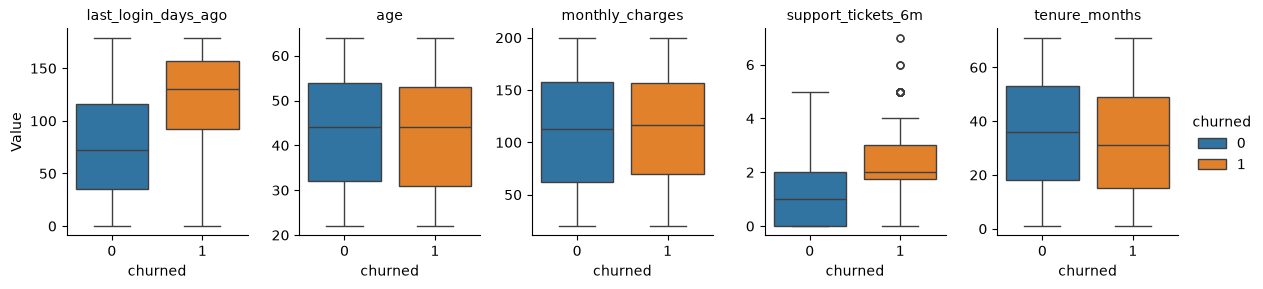

In [5]:
factor_cols = set(["customer_id", "churned" ,"has_support_contract", "num_products"])
numeric_cols = set(df.columns) - factor_cols

df_plot = df.drop(columns=["has_support_contract"]).melt(
    id_vars=["customer_id", "churned"],
    value_vars=numeric_cols,
    var_name="Variable",
    value_name="Value"
)
g = sns.catplot(
    data=df_plot,
    x="churned", y="Value", hue="churned",
    col="Variable",
    kind="box",
    sharey=False,
    height=3,
    aspect=0.8
)
g.set_titles("{col_name}")

<Axes: xlabel='num_products', ylabel='count'>

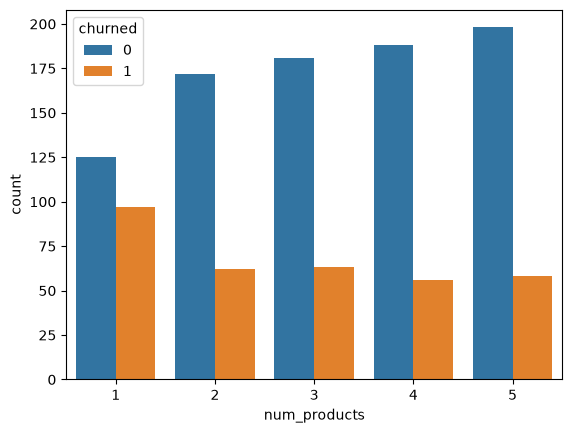

In [6]:
sns.countplot(data=df, x="num_products", hue="churned")


In [7]:
table_ = pd.crosstab(df["has_support_contract"], df["churned"])
table_

churned,0,1
has_support_contract,,
0,436,177
1,428,159


Lo que observo es:

1. Los usuarios que han incurrido en churn acumulan más días desde su último login.
2. Adicionalmente, estos mismos usuarios también han solicitado más tickets de soporte en los últimos 6 meses, típicamente 2 o más.
3. Tener más productos contratados, reduce el riesgo de churn, aunque el salto de mayor magnitud está en tener más de un producto contratado.
4. Los clientes que incurrieron en churn fueron clientes durante una cantidad de meses ligeramente menor.
5. El resto de variables no parecen influir en el riesgo de churn a nivel marginal, lo que no implica que sí que influyan en interacción con otras variables.

Sin entrenar nada, ya podríamos tener algunas reglas para evitar el churn:
- Si un cliente lleva más de 100 días sin login sería conveniente llamar o enviar un correo.
- Si un cliente acumula 2 o más tickets de soporte en los últimos 6 meses convendría elaborar alguna estrategia para compensarlo.
- Sería interesante ofrecer packs de 2 productos por un precio reducido.

Nota: todo esto podría complementarse con tests estadísticos, pero por simplicidad voy a obviar ese aspecto.

## Parte 2 - Modelado

4. Prepara los datos: separa features y target, realiza un split train/test (80/20) y aplica cualquier preprocesado que consideres necesario. Justifica tus decisiones.

5. Entrena al menos un modelo de clasificación. Evalúa su rendimiento con las métricas que consideres más adecuadas para este problema de negocio. Justifica la elección de métricas.

Se trata de un problema de clasificación binaria donde hay que predecir el churn en función del resto de características. De estas características, excluyo el ``customer_id`` porque es un número asignado al azar que sirve para identificar usuarios, no aporta información. Como voy a seleccionar un modelo basado en árboles, no voy a aplicar ningún preprocesado. Si utilizara algún otro tipo de modelo donde es necesario un tratamiento numérico de las variables (regresión lineal, regresión logística), sí convendría rescalar variables y aplicar one-hot-encoding a ``num_products``.

Por mantener la simplicidad, no voy tampoco a implementar ningún algoritmo de generación de datos sintéticos como SMOTE. Voy a centrarme en paliar el desbalance a nivel de modelo más que a nivel de dato.

Como modelo, escojo un random forest, ya que me parece un buen equilibrio entre sesgo y varianza para este problema. Un árbol simple es más interpretable pero la varianza podría ser grande. Por otra parte, algoritmos más complejos como XGBoost o redes neuronales podrían evaluarse pero quizá puedan incurrir también en una varianza alta produciendo sobreajuste. De todas formas, lo dejo implementado de forma que es casi trivial añadir nuevos modelos. Adicionalmente, implemento una referencia o Baseline que simplemente asigna churn si el número de tickets en los últimos 6 meses es mayor o igual que 2.

Voy a definir también un pequeño grid de híper-parámetros para hacer grid search sobre los híper-parámetros que afectan a la complejidad del modelo como ``max_depth``, ``min_samples_leaf`` o ``n_estimators``. Adicionalmente, añado dos posibles estrategias para paliar el desbalance entre clases: 1) ``"balanced"`` donde se calcula un peso para cada clase en función de su proporción en el conjunto de datos global ponderando más la clase desbalanceada, 2) ``"balanced_subsample"`` se hace lo mismo pero dentro de cada conjunto de datos bootstrap muestreado para cada árbol del random forest. Hay otra estrategia que permite asignar pesos personalizados a cada clase, pero esto habría que calibrarlo con negocio, ya que aumentar mucho el peso de churn positivo (clase desbalanceada) podría resultar en muchos falsos positivos, haciendo trabajar a alguien de más con alta probabilidad. Probablemente, haya estrategias más sofisticadas para la búsqueda de híper-parámetros pero para este problema me parece hacer overengineering.

Para esta búsqueda de híper-parámetros, escojo implementar cross-validation con 3 folds para aumentar la robustez estadística a la hora de buscar el modelo óptimo. Puedo hacer esto porque el conjunto de datos es relativamente pequeño y random forest no es tan computacionalmente limitante para la mayoría de PC retail, en otro tipo de problemas esto es prohibitivo. Por otra parte, escojo el modelo óptimo en base a F1 ya que tiene en cuenta Recall y Precision. Si la detección de churn fuera híper-crítica y los FP carecieran de relevancia podría optarse por Recall.

In [8]:
target = "churned"
excluded_features = [target, "customer_id"]
training_features = [cname for cname in df.columns if cname not in excluded_features]
random_state = 42
hparam_grids = {
    "random_forest": {
        "model__max_depth": [1, 3, 10, 50],
        "model__min_samples_leaf": [3, 10, 30, 50],
        "model__n_estimators": [10, 50, 100],
        "model__class_weight": ["balanced", "balanced_subsample"],
        "model__criterion": ["gini", "entropy"],
        "model__max_features": ["sqrt", None],
        "model__random_state": [random_state]
    },
    "baseline": {}
}
n_cv_splits = StratifiedShuffleSplit(
    n_splits=3,
    test_size=0.2,
    random_state=random_state
)

In [9]:
X = df[training_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [10]:
preprocessors = [
    ColumnTransformer(
        transformers=[],
        remainder="passthrough"
    ),
    "passthrough"
]
models = [
    RandomForestClassifier(),
    ThresholdRuleClassifier(column="support_tickets_6m", threshold=2, operator=">=")
]
names = ["random_forest", "baseline"]
prep_model_name = zip(preprocessors, models, names)
pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", prep),
        ("model", model_)
    ]) for prep, model_, name in prep_model_name
}

In [11]:
best_models = {}
for model_name, pipe in pipelines.items():
    model_instance = pipe.steps[-1][-1]
    if isinstance(model_instance, ThresholdRuleClassifier):
        pipe.fit(X_train, y_train)
        best_models[model_name] = pipe
    else:
        hparam_search = GridSearchCV(
            pipe,
            param_grid=hparam_grids[model_name],
            scoring="f1",
            cv=n_cv_splits,
            n_jobs=-1
        )
        hparam_search.fit(X_train, y_train)
        best_models[model_name] = hparam_search.best_estimator_
    

In [12]:
best_models["random_forest"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','tenure_months','monthly_charges',...,'has_support_contract', 'last_login_days_ago','support_tickets_6m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.",[]
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [13]:
results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    results[name] = {
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

pd.DataFrame(results).T

,precision,recall,f1
random_forest,0.529412,0.671642,0.592105
baseline,0.411215,0.656716,0.505747


Simplemente con la regla "Baseline" de alertar de churn si el número de tickets en los últimos 6 meses es mayor o igual que 2 ya estamos obteniendo Recall comparable a la del modelo. Sin embargo, Precision sí es significativamente mayor en el caso de random forest. En otras palabras, random forest y la regla "Baseline" tienen una capacidad de detección de churn similar; sin embargo, la regla tiende a dar más alertas falsas.

6. Muestra e interpreta la importancia de variables (feature importance o similar). ¿Qué variables son más relevantes para predecir el churn?

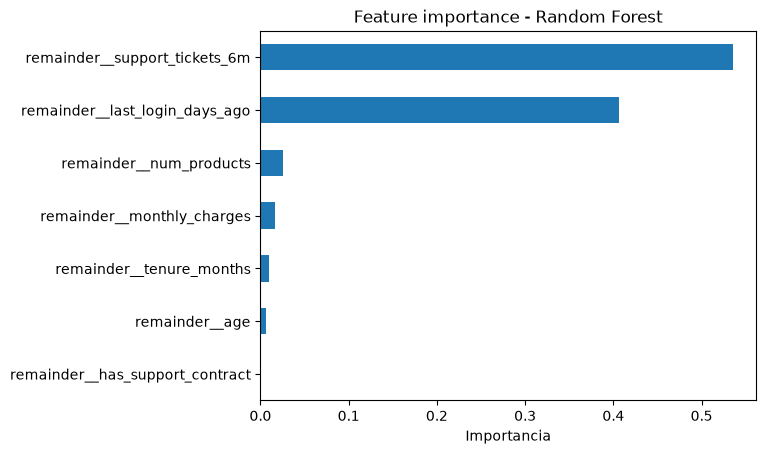

In [14]:
rf_pipeline = best_models["random_forest"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.plot(kind="barh")
plt.xlabel("Importancia")
plt.title("Feature importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

Muy en línea con lo que habíamos visto en el análisis exploratorio, el número de tickets en los últimos 6 meses y los días desde el último login dominan prácticamente. El resto de variables tienen una importancia residual.

## Parte 3 - Reflexión

7. ¿Qué harías para llevar este modelo a producción? Describe brevemente (3-5 puntos) los pasos que seguirías: API, monitorización, reentrenamiento, etc.

Soy honesto aquí, pese a que varios de mis modelos están desplegados y dan servicio a hospitales, no tengo tanta experiencia desplegando yo mismo los modelos. Probablemente, sí que añadiría un Dockerfile con el modelo serializado quizá y le añadiría una FastAPI sencilla. Después, pues investigaría las posibilidades de despliegue de algún proveedor cloud, seguramente AWS porque es con el que más familiarizado estoy. Sé que SageMaker facilita todo el flujo de entrenamiento y despliegue, sería una opción a tener en cuenta. Para monitorización pues también investigaría qué puedo hacer dentro de AWS, combinar SageMaker con CloudWatch para evaluar drift en las distribuciones de los inputs o la evolución temporal de la proporción de positivos (churn). Para re-entrenamiento, probablemente combinar la posibilidad de desencadenarlo manualmente, junto con re-entrenamiento periódico basado en la disponibilidad de datos o en intervalos fijos de tiempo podría ser una primera aproximación. Pero reitero, mi experiencia en despliegue es más bien limitada, ya que en mi sector re-entrenar un modelo y desplegarlo conlleva barreras regulatorias significativas.

8. Si tuvieras más tiempo, ¿qué mejorarías del análisis o del modelo?

Probablemente, la calidad de los plots, añadiría alguna métrica de latencia, estudiaría los outliers, discutiría curva ROC junto con AUC, probaría otros modelos, quizá miraría estrategias alternativas para la búsqueda de híper-parámetros, estudiaría interacciones entre variables, investigaría más sobre el churn tanto a nivel local dentro de la propia compañía (colaborando con otros departamentos) como a nivel científico ya que es un problema de clasificación binaria y hay bastante literatura sobre esto. Aunque bueno, seguro que tanto mi propuesta en este notebook como esta reflexión son mejorables.